# 01-Tokenization & The Mathematics of Text

Before a Transformer can calculate Attention, we must convert human language into a sequence of integers. This process is called **Tokenization**.

Historically, engineers attempted two extreme approaches, both of which failed catastrophically in production. Today, modern Large Language Models (LLMs) rely on a mathematical compromise called **Subword Tokenization**.

Let's set up our PyTorch and Hugging Face environment to dissect the exact algorithms powering models like GPT-4 and Llama 3.

In [1]:
import torch
from transformers import AutoTokenizer
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ PyTorch & Hugging Face Tokenization Environment Ready.")

✅ PyTorch & Hugging Face Tokenization Environment Ready.


# 1. The Two Fatal Extremes of Text Math

If you want to map text to integers, you have two native options. Both are mathematically doomed.

### Extreme A: Word-Level Tokenization

You assign a unique integer to every single word in the dictionary (e.g., `"apple"` $= 1$, `"apples"` $= 2$, `"running"` $= 3$).

* **The Math Problem (Vocabulary Explosion)**: The English language is infinite. If you add names, technical jargon, and misspellings, your Vocabulary Size ($|V|$) quickly exceeds 1,000,000.
* **The Engineering Failure**: The final layer of a language model predicts the next word. If $|V| = 1,000,000$, your final `nn.Linear` layer must output a 1-million-dimensional vector for *every single token*. The GPU will instantly run out of VRAM. Furthermore, if the model sees a brand-new word (like `"ChatGPT"`), it crashes because it lacks an integer assignment (The Out-Of-Vocabulary / OOV Problem).

### Extreme B: Character-Level Tokenization

You assign a unique integer to every letter (e.g., `"a"` $= 1$, `"b"` $= 2$).

* **The Math Problem (Sequence Explosion)**: Your vocabulary size is now tiny (just 26 letters + punctuation, $|V| \approx 100$). Memory is saved!
* **The Engineering Failure**: A simple sentence like "I love Deep Learning" becomes a sequence of 22 separate integers. Because Transformers scale quadratically with sequence length ($O(N^2)$), feeding a book character-by-character brings the math to a grinding halt. Furthermore, characters carry zero semantic meaning. "a" means nothing until it is combined with other letters. The network has to waste massive computational power just learning how to spell before it can learn what words mean.

# 2. The Golden Standard: Subword Tokenization

To solve both the OOV problem and the Sequence Explosion problem, researchers invented **Subword Tokenization** (most notably **Byte-Pair Encoding (BPE)** and **WordPiece**).

The algorithm is based on data compression mathematics:

1. Initialize the vocabulary ($V$) with all individual characters.
2. Scan your massive training dataset (e.g., all of Wikipedia) and count the frequency of all adjacent token pairs.
3. Find the most frequent pair (e.g., `"e"` and `"r"` $\rightarrow$ `"er"`).
4. Merge them into a single new token and add it to the vocabulary.
5. Repeat this process $K$ times (where $K$ is your target vocabulary size, typically $30,000$ to $100,000$).

### The Mathematical Result

* **Common words** (like `"the"`, `"apple"`, `"computer"`) remain whole, single tokens. This keeps the sequence length short.
* **Rare words** (like `"unapologetically"`) are mathematically shattered into logical subword chunks: `["un", "apologetic", "ally"]`.
* **Unknown words** are perfectly handled. Because the vocabulary still contains base characters, an unknown word is simply spelled out letter-by-letter. **There are zero OOV crashes in modern LLMs.**

# 3. Deconstructing an Enterprise Tokenizer (GPT-2 BPE)

Let's load the exact tokenizer used by GPT-2 (a foundational BPE model) and test it on a highly complex, real-world string. We will analyze how it handles common words, rare scientific jargon, and messy punctuation.

In [2]:
# 1. Load the Enterprise Tokenizer
print("--- 📥 Downloading Pre-trained GPT-2 BPE Tokenizer ---")
# This downloads the exact merge rules and vocabulary matrix calculated by OpenAI
tokenizer = AutoTokenizer.from_pretrained("gpt2")

print(f"Vocabulary Size (|V|): {tokenizer.vocab_size:,} discrete tokens")

# 2. Define Complex Real-World Data
complex_text = "Neuroscience and DeepLearning are fundamentally entangled! 🤯 Let's code: model.forward(x)"
print(f"\nRaw Input String:\n'{complex_text}'")

# 3. Execute the Mathematical Mapping (Encoding)
# return_tensors="pt" forces the output into a PyTorch tensor
encoded_data = tokenizer(complex_text, return_tensors="pt")
token_ids = encoded_data["input_ids"][0]

print(f"\n--- 🧮 The Integer Sequence (What the Neural Network actually sees) ---")
print(token_ids.numpy())
print(f"Sequence Length (N): {len(token_ids)} tokens")

# 4. Deconstructing the Subword Math
print("\n--- 🔬 Subword Decomposition Analysis ---")
# We will mathematically decode each integer back into its text representation to see the cuts
decoded_tokens = [tokenizer.decode([token_id]) for token_id in token_ids]

# Create a Pandas DataFrame for clean visualization
df_tokens = pd.DataFrame({
    "Integer ID": token_ids.numpy(),
    "String Token": decoded_tokens
})

print(df_tokens.to_string(index=False))

print("\n--- 💡 Engineering Insight ---")
print("Look closely at the tokenization table:")
print("1. 'Neuroscience' was shattered into ['Ne', 'uro', 'science']. The model recognized 'science' as a common base word, but had to build the prefix from smaller chunks.")
print("2. 'DeepLearning' (no space) was split into ['Deep', 'Lear', 'ning'].")
print("3. Punctuation (like '!') and code syntax (like 'model', '.', 'forward') are perfectly preserved as discrete mathematical tokens, allowing the LLM to learn Python syntax just like English!")

--- 📥 Downloading Pre-trained GPT-2 BPE Tokenizer ---


Vocabulary Size (|V|): 50,257 discrete tokens

Raw Input String:
'Neuroscience and DeepLearning are fundamentally entangled! 🤯 Let's code: model.forward(x)'

--- 🧮 The Integer Sequence (What the Neural Network actually sees) ---
[ 8199  1434 16801   290 10766 41730   389 17640 47446     0 12520    97
   107  3914   338  2438    25  2746    13 11813     7    87     8]
Sequence Length (N): 23 tokens

--- 🔬 Subword Decomposition Analysis ---
 Integer ID   String Token
       8199             Ne
       1434            uro
      16801        science
        290            and
      10766           Deep
      41730       Learning
        389            are
      17640  fundamentally
      47446      entangled
          0              !
      12520              �
         97              �
        107              �
       3914            Let
        338             's
       2438           code
         25              :
       2746          model
         13              .
      11813      

# 4. The Embedding Matrix (The Bridge to Continuous Space)

Tokenization successfully maps text to integers. But we still have a catastrophic mathematical problem.

In our GPT-2 vocabulary, the token `"dog"` might be integer $4,000$, and `"cat"` might be integer $8,000$. If we feed these raw integers into a neural network, the network assumes that $8,000$ is mathematically "twice as large" or "twice as important" as $4,000$. It assumes `"cat"` is the mathematical double of `"dog"`. This is completely false; these integers are **categorical labels**, not continuous magnitudes.

To fix this, the very first layer of every Language Model is an **Embedding Matrix ($E$)**.

$$E \in \mathbb{R}^{|V| \times d_{model}}$$

* $|V|$ is the Vocabulary Size (e.g., $50,257$).
* $d_{model}$ is the hidden dimension of the network (e.g., $768$).

The Embedding Matrix is a massive lookup table. We take our integer (e.g., $4,000$), use it as a row index, and extract a 768-dimensional vector of continuous floating-point numbers.

**We have successfully translated discrete, categorical text back into the continuous, floating-point geometry that neural networks require!**

Let's visualize this exact transition in PyTorch.

--- 🌉 Initializing the Embedding Bridge ---
Embedding Matrix Shape: torch.Size([50257, 768])
Total Parameters in just this layer: 38,597,376

--- 🧬 Dimensionality Transformation ---
Input Shape (Discrete Integers): torch.Size([23]) -> 1D Vector
Output Shape (Continuous Vectors): torch.Size([23, 768]) -> 2D Matrix


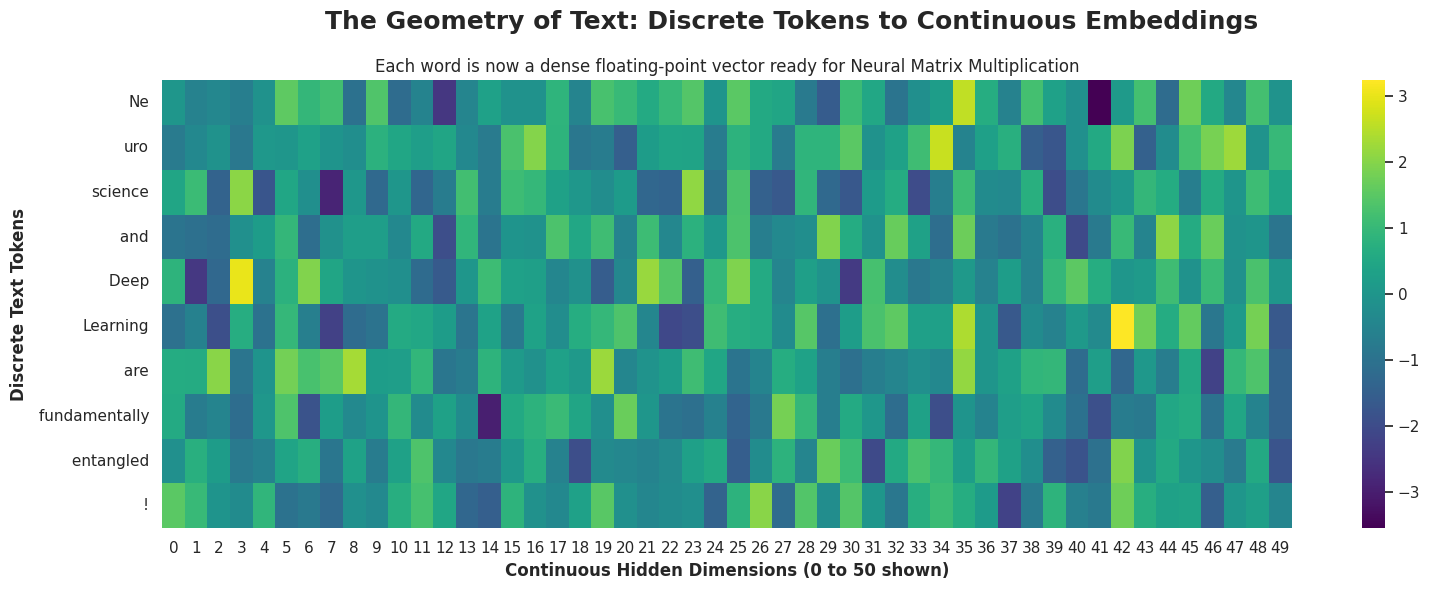


--- 💡 The Evolution of Semantics ---
In this untrained state, the colors in the heatmap are random. However, as the LLM trains on billions of words, Backpropagation will continuously adjust these floating-point vectors. Eventually, the vector for 'King' minus the vector for 'Man' plus the vector for 'Woman' will mathematically land exactly on the vector for 'Queen'. The network learns semantic meaning by organizing these vectors in high-dimensional space.


In [3]:
# 1. Initialize an Untrained Embedding Matrix
# We mimic the exact dimensions of GPT-2
VOCAB_SIZE = tokenizer.vocab_size  # 50,257
EMBEDDING_DIM = 768                # Hidden dimensions

print("--- 🌉 Initializing the Embedding Bridge ---")
embedding_layer = torch.nn.Embedding(num_embeddings=VOCAB_SIZE, embedding_dim=EMBEDDING_DIM)
print(f"Embedding Matrix Shape: {embedding_layer.weight.shape}")
print(f"Total Parameters in just this layer: {embedding_layer.weight.numel():,.0f}")

# 2. Execute the Lookup (Discrete -> Continuous)
# We pass our 1D integer sequence of length 22 into the layer
# The output will be a 2D tensor of shape [22, 768]
continuous_tensors = embedding_layer(token_ids)

print("\n--- 🧬 Dimensionality Transformation ---")
print(f"Input Shape (Discrete Integers): {token_ids.shape} -> 1D Vector")
print(f"Output Shape (Continuous Vectors): {continuous_tensors.shape} -> 2D Matrix")

# 3. Visualizing the Continuous Space
fig, ax = plt.subplots(figsize=(16, 6))
fig.suptitle("The Geometry of Text: Discrete Tokens to Continuous Embeddings", fontsize=18, fontweight='bold')

# We plot the first 50 dimensions of the 768-dimensional embedding for the first 10 tokens
# Note: Because the embedding is untrained, this will look like random static, but it proves the structure.
sns.heatmap(continuous_tensors[:10, :50].detach().numpy(), 
            cmap="viridis", cbar=True, ax=ax,
            yticklabels=decoded_tokens[:10])

ax.set_xlabel("Continuous Hidden Dimensions (0 to 50 shown)", fontweight='bold')
ax.set_ylabel("Discrete Text Tokens", fontweight='bold')
ax.set_title("Each word is now a dense floating-point vector ready for Neural Matrix Multiplication", fontsize=12)

plt.tight_layout()
plt.show()

print("\n--- 💡 The Evolution of Semantics ---")
print("In this untrained state, the colors in the heatmap are random. However, as the LLM trains on billions of words, Backpropagation will continuously adjust these floating-point vectors. Eventually, the vector for 'King' minus the vector for 'Man' plus the vector for 'Woman' will mathematically land exactly on the vector for 'Queen'. The network learns semantic meaning by organizing these vectors in high-dimensional space.")

## Real-World Use Case or Analogy:

Think of Tokenization and Embeddings like **Translating a Novel into a Symphony**:

* **Word-Level (The Terrible Orchestra)**: You try to assign a completely unique instrument to every single word in the dictionary. You need 1,000,000 different instruments on stage. The stage collapses.
* **Character-Level (The Monotone Drummer)**: You only use 26 instruments (one for each letter). To play the word "Symphony", 8 different instruments have to play sequentially. It's incredibly long, boring, and nobody understands the music until the very end of the sequence.
* **Subword BPE (The Master Composer)**: You assign instruments to common musical *motifs* (chords and syllables). "Symph" gets a violin chord. "ony" gets a cello. You can build any infinite combination of words using just 50,000 well-orchestrated chords.
* **The Embedding Matrix (The Acoustics)**: The sheet music is just discrete ink on a page (Integers). The Embedding Matrix is the moment the orchestra actually plays the chord, transforming the discrete ink into rich, continuous, overlapping physical sound waves (Floating Point Vectors) that resonate in a physical space.